In [ ]:
# 📦 Step 1: Install dependencies (run in terminal beforehand if needed)
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# pip install diffusers transformers accelerate safetensors
# pip install git+https://github.com/tencent-ailab/IP-Adapter.git

In [ ]:
import os
gpu_ids = [2]
os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(map(str, gpu_ids))

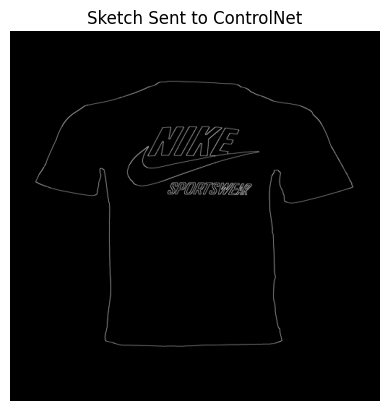

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

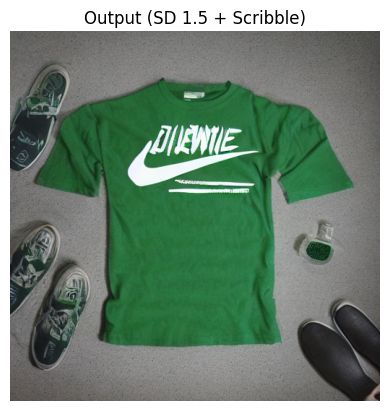

In [ ]:

from PIL import Image, ImageEnhance, ImageOps
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from diffusers.utils import load_image

# Setup GPU
gpu_ids = [2]
os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(map(str, gpu_ids))

# Paths and prompt
original_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/standalone_shirts/1164.jpg"
sketch_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/sketches/1164_sketch.png"
feature_path = "/data/home/huixian/Documents/677_project/fashion/fashion-dataset/features/1164_feature.png"
prompt = "green down tshirt"

# Load and preprocess images
original_image = load_image(original_path).resize((512, 512)).convert("RGB")

sketch_image = Image.open(sketch_path).resize((512, 512)).convert("L")
sketch_image = ImageOps.invert(sketch_image)
sketch_image = ImageEnhance.Contrast(sketch_image).enhance(2.0).convert("RGB")

feature_image = Image.open(feature_path).resize((512, 512)).convert("L")
feature_image = ImageOps.invert(feature_image)
feature_image = ImageEnhance.Contrast(feature_image).enhance(2.0).convert("RGB")

# Visual check
plt.imshow(original_image)
plt.title("Sketch Sent to ControlNet")
plt.axis("off")
plt.show()

# Visual check
plt.imshow(sketch_image)
plt.title("Sketch Sent to ControlNet")
plt.axis("off")
plt.show()


# Visual check
plt.imshow(feature_image)
plt.title("Sketch Sent to ControlNet")
plt.axis("off")
plt.show()

# Load ControlNet for SD 1.5 (Scribble)
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/control_v11p_sd15_scribble",
    torch_dtype=torch.float16
).to("cuda")

# Load Stable Diffusion v1.5 with ControlNet
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

pipe.enable_attention_slicing()

# Generate image
with torch.inference_mode(), torch.autocast("cuda"):
    result = pipe(
        prompt=prompt,
        image=sketch_image,
        num_inference_steps=35,
        guidance_scale=8.5
    ).images[0]

# Show result
plt.imshow(result)
plt.title("Output (SD 1.5 + Scribble)")
plt.axis("off")
plt.show()


  0%|          | 0/20 [00:00<?, ?it/s]

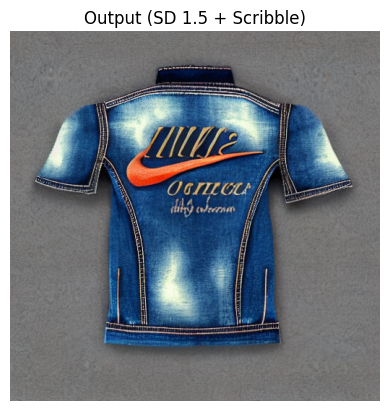

In [96]:
prompt = "denim jacket"
with torch.inference_mode(), torch.autocast("cuda"):
    result = pipe(
        prompt=prompt,
        image=sketch_image,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images[0]

# Show result
plt.imshow(result)
plt.title("Output (SD 1.5 + Scribble)")
plt.axis("off")
plt.show()

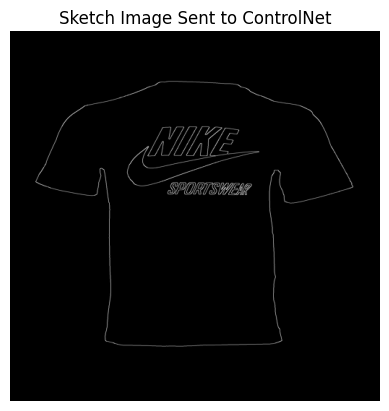

In [72]:
plt.imshow(sketch_image)
plt.title("Sketch Image Sent to ControlNet")
plt.axis("off")
plt.show()
